# 協会けんぽの5つのKPIから保険料率を予測

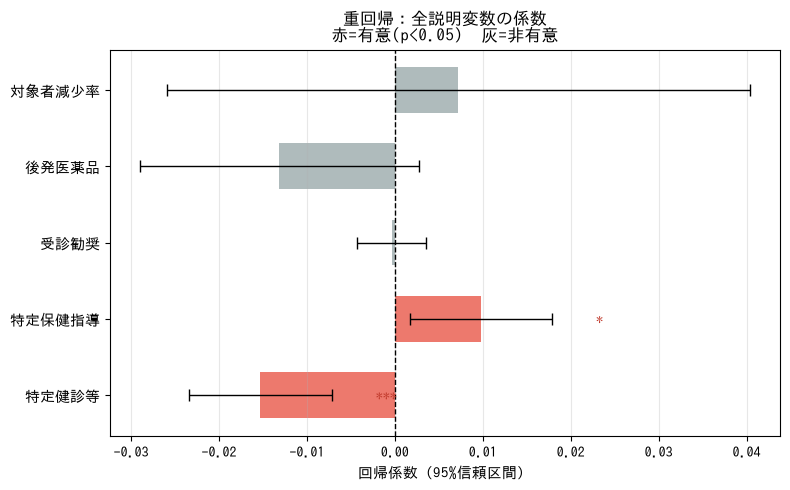


【重回帰結果】
  R²: 0.1350
  Adj. R²: 0.1029

各説明変数の係数・p値:
            係数      p値
特定健診等  -0.0153  0.0003
特定保健指導  0.0098  0.0181
受診勧奨   -0.0004  0.8522
後発医薬品  -0.0131  0.1038
対象者減少率  0.0072  0.6676
                            OLS Regression Results                            
Dep. Variable:               翌々年度保険料率   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     4.213
Date:                Fri, 03 Jul 2026   Prob (F-statistic):            0.00137
Time:                        10:15:50   Log-Likelihood:                -6.9358
No. Observations:                 141   AIC:                             25.87
Df Residuals:                     135   BIC:                             43.56
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 c

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（IPAGothic）
matplotlib.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

# データ読み込み（v2: 病床数・地域差指数・県民所得を追加）
df = pd.read_csv('../data/分析用データ.tsv', sep='\t')
df = df.dropna()

# データ表示
# print(f"カラム ({len(df.columns)}個): {list(df.columns)}")
# print(f"データ件数: {len(df)} 行")
# print(f"年度: {sorted(df['年度'].unique())}")
# df.head()


## 重回帰モデル（全パラメーター）
feature_cols = [
    '特定健診等',       # 予防・健診系 KPI
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率'
]

X_multi = sm.add_constant(df[feature_cols])
y = df['翌々年度保険料率']

model_multi = sm.OLS(y, X_multi).fit()


## 係数プロット（全パラメーター重回帰）
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

# 左：係数と95%信頼区間（有意なものを赤で）
coefs = model_multi.params[1:]
conf = model_multi.conf_int().iloc[1:]
pvals = model_multi.pvalues[1:]
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in pvals]

ax = axes
y_pos = range(len(coefs))
ax.barh(y_pos, coefs.values, color=colors, alpha=0.75, height=0.6)
ax.errorbar(coefs.values, y_pos,
            xerr=[coefs.values - conf[0].values, conf[1].values - coefs.values],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs.index, fontsize=11)
ax.set_xlabel('回帰係数（95%信頼区間）', fontsize=11)
ax.set_title('重回帰：全説明変数の係数\n赤=有意(p<0.05)  灰=非有意', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

# p値アノテーション
for i, (c, p) in enumerate(zip(coefs.values, pvals)):
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    if sig:
        ax.text(c + (conf[1].iloc[i] - c) + 0.005, i, sig,
                va='center', fontsize=10, color='#c0392b')

# 右：実測値 vs 予測値
# y_pred_multi = model_multi.fittedvalues
# ax2 = axes[1]
# ax2.scatter(y, y_pred_multi, alpha=0.5, color='steelblue', s=40)
# lims = [min(y.min(), y_pred_multi.min()) - 0.05,
#         max(y.max(), y_pred_multi.max()) + 0.05]
# ax2.plot(lims, lims, 'r--', linewidth=1.5, label='完全予測線')
# ax2.set_xlabel('実測値（翌々年度保険料率）', fontsize=11)
# ax2.set_ylabel('予測値', fontsize=11)
# ax2.set_title(f'実測値 vs 予測値\nR²={model_multi.rsquared:.3f}  Adj.R²={model_multi.rsquared_adj:.3f}', fontsize=12)
# ax2.legend(fontsize=10)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n【重回帰結果】")
print(f"  R²: {model_multi.rsquared:.4f}")
print(f"  Adj. R²: {model_multi.rsquared_adj:.4f}")
print("\n各説明変数の係数・p値:")
print(pd.DataFrame({
    '係数': model_multi.params[feature_cols],
    'p値': model_multi.pvalues[feature_cols],
}).round(4))

print(model_multi.summary())

In [71]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

def r_square(y_test, y_pred):
    avg_y_test = sum(y_test)/len(y_test)
    sse = sum(map(lambda t, p: (t - p)**2, y_test, y_pred))
    sst = sum(map(lambda t: (t - avg_y_test)**2, y_test))
    return 1 - sse/sst

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

x = df[feature_cols].to_numpy()
y = df['翌々年度保険料率'].to_numpy()

for fold, (train_idx, test_idx) in enumerate(kf.split(x), start=1):
    X_train, X_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    X_multi = sm.add_constant(X_train)

    model_multi = sm.OLS(y_train, X_train).fit()

    y_pred = model_multi.predict(X_test)

    print(y_train[0:5], y_pred[0:5])

    cv_rows.append({
        'fold': fold,
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        # 'MAE': mean_absolute_error(y_test, y_pred),
        # 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })

cv_results = pd.DataFrame(cv_rows)
# cv_summary = cv_results[['MAE', 'RMSE', 'R2']].agg(['mean', 'std']).T
cv_summary = cv_results[['R2']].agg(['mean', 'std']).T
cv_summary.columns = ['平均', '標準偏差']

print('\n【5-fold CV評価】')
print(cv_summary.round(4))
print('\nfold別結果:')
print(cv_results.round(4))

[10.39 10.03  9.91 10.18  9.99] [10.02029831  9.71100854  9.76515406  9.84807257  9.71255351]
[10.03  9.91 10.18 10.27  9.99] [9.81970897 9.76417912 9.56549107 9.49789545 9.57022231]
[10.39 10.03  9.91 10.18 10.27] [9.95139313 9.61233035 9.76732267 9.74427697 9.75151398]
[10.39 10.03  9.91 10.27  9.99] [ 9.8218431  10.07120835  9.76915251  8.9964229  10.02960079]
[10.39 10.18 10.27  9.99  9.65] [ 9.79792057 10.00503508  9.97801607  9.7769651  10.01478885]

【5-fold CV評価】
        平均    標準偏差
R2 -1.1912  0.7987

fold別結果:
   fold  n_train  n_test      R2
0     1      112      29 -0.5068
1     2      113      28 -0.3354
2     3      113      28 -1.4234
3     4      113      28 -2.3152
4     5      113      28 -1.3751


In [72]:
X_multi = sm.add_constant(df[feature_cols])
y = df['翌々年度保険料率']

model_multi = sm.OLS(y, X_multi).fit()
y_pred = model_multi.predict(X_multi)
r2_score(y, model_multi.predict(X_multi))

0.13497092590422766